In [9]:
import pandas as pd

df = pd.read_csv("/content/Student_Performance_Dataset.csv")

df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [10]:
df.shape


(5000, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

In [12]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Class,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Parental_Education,0
Internet_Access,0
Extracurricular_Activities,0
Math_Score,0


In [13]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


In [14]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='object')

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(["Student_ID", "Final_Percentage"], axis=1)

y = df["Final_Percentage"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 14)
X_test shape: (1000, 14)
y_train shape: (4000,)
y_test shape: (1000,)


In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numerical Features:
Index(['Age', 'Class', 'Study_Hours_Per_Day', 'Attendance_Percentage',
       'Math_Score', 'Science_Score', 'English_Score', 'Previous_Year_Score'],
      dtype='object')

Categorical Features:
Index(['Gender', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Performance_Level', 'Pass_Fail'],
      dtype='object')


In [17]:
X = df.drop(
    ["Student_ID", "Final_Percentage", "Performance_Level", "Pass_Fail"],
    axis=1
)

y = df["Final_Percentage"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 12)
X_test shape: (1000, 12)
y_train shape: (4000,)
y_test shape: (1000,)


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Redefine numeric and categorical features based on the updated X
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Redefine the preprocessor after X has been updated
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)


Linear Regression Results
MAE: 0.002278949435489743
MSE: 7.4738738462429315e-06
RMSE: 0.0027338386649988933
R2 Score: 0.9999999371025602


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numerical Features:
Index(['Age', 'Class', 'Study_Hours_Per_Day', 'Attendance_Percentage',
       'Math_Score', 'Science_Score', 'English_Score', 'Previous_Year_Score'],
      dtype='object')

Categorical Features:
Index(['Gender', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities'],
      dtype='object')


In [22]:
X = df.drop(
    [
        "Student_ID",
        "Final_Percentage",
        "Performance_Level",
        "Pass_Fail",
        "Math_Score",
        "Science_Score",
        "English_Score"
    ],
    axis=1
)

y = df["Final_Percentage"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [24]:
X = df.drop(
    [
        "Student_ID",
        "Final_Percentage",
        "Performance_Level",
        "Pass_Fail",
        "Math_Score",
        "Science_Score",
        "English_Score"
    ],
    axis=1
)

y = df["Final_Percentage"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 9.1577398
MSE: 126.16410287795999
RMSE: 11.232279504978496
R2 Score: -0.06175180794886459


In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Results
MAE: 9.020337999618398
MSE: 121.72322737320032
RMSE: 11.032824995131588
R2 Score: -0.0243789935864831


In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gb
    ],
    "MSE": [
        mse_lr,
        mse_rf,
        mse_gb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.002279,0.000007,0.002734,1.000000
1,Random Forest,9.157740,126.164103,11.232280,-0.061752
2,Gradient Boosting,9.020338,121.723227,11.032825,-0.024379


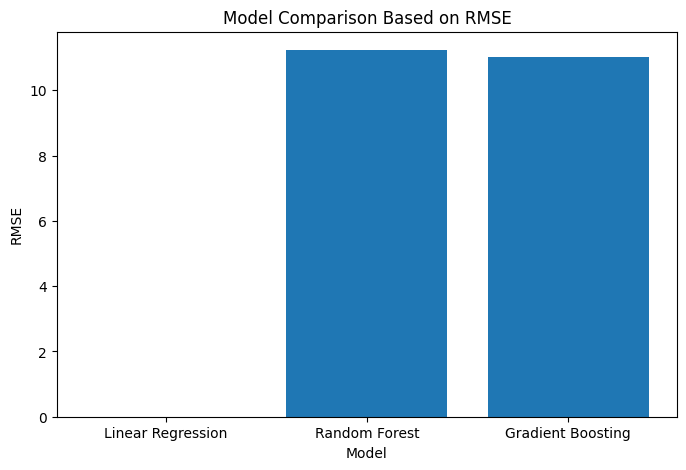

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

In [31]:
feature_names = (
    numeric_features.tolist() +
    list(
        rf_model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
2,Study_Hours_Per_Day,0.223316
3,Attendance_Percentage,0.215467
4,Previous_Year_Score,0.215424
0,Age,0.095235
1,Class,0.072582
7,Parental_Education_Graduate,0.023651
9,Parental_Education_Postgraduate,0.023334
8,Parental_Education_High School,0.022512
5,Gender_Female,0.019434
11,Internet_Access_Yes,0.019256


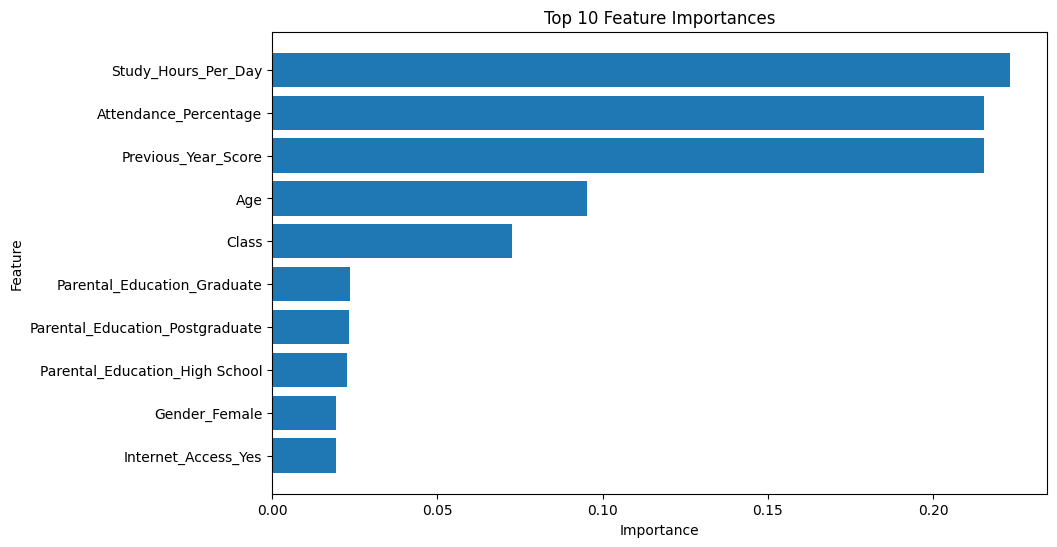

In [32]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

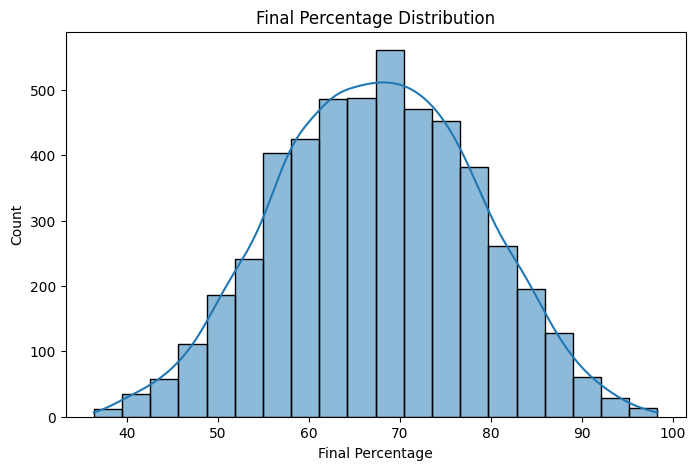

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["Final_Percentage"], bins=20, kde=True)

plt.title("Final Percentage Distribution")
plt.xlabel("Final Percentage")
plt.ylabel("Count")

plt.show()

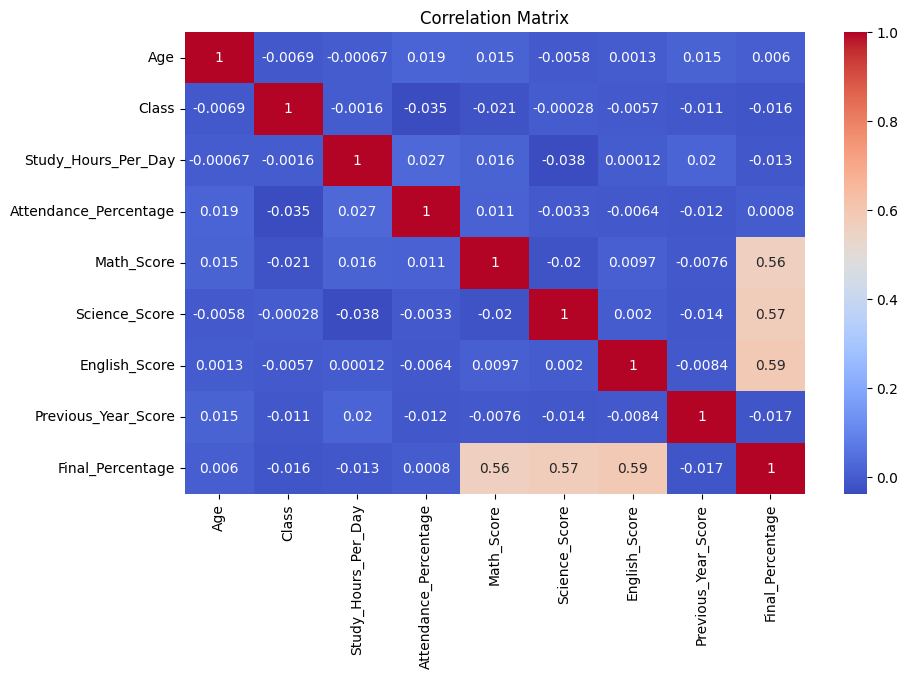

In [34]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

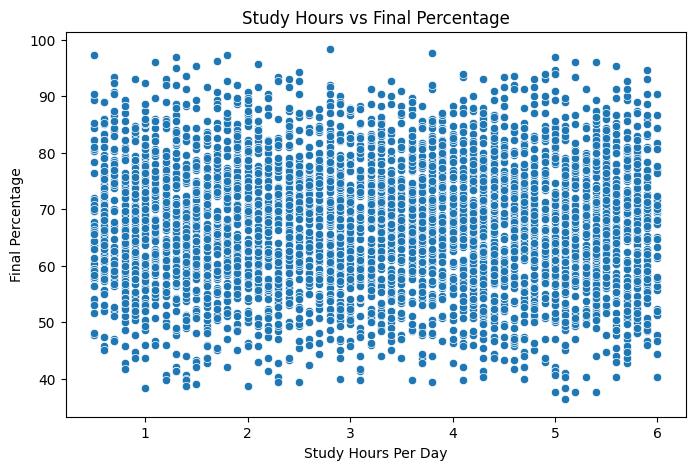

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Study_Hours_Per_Day"],
    y=df["Final_Percentage"]
)

plt.title("Study Hours vs Final Percentage")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Final Percentage")

plt.show()

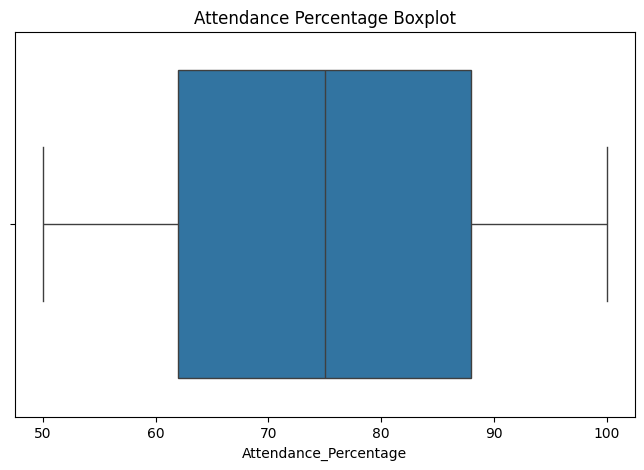

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Attendance_Percentage"])

plt.title("Attendance Percentage Boxplot")

plt.show()

In [37]:
df["average_score"] = (
    df["Math_Score"] +
    df["Science_Score"] +
    df["English_Score"]
) / 3

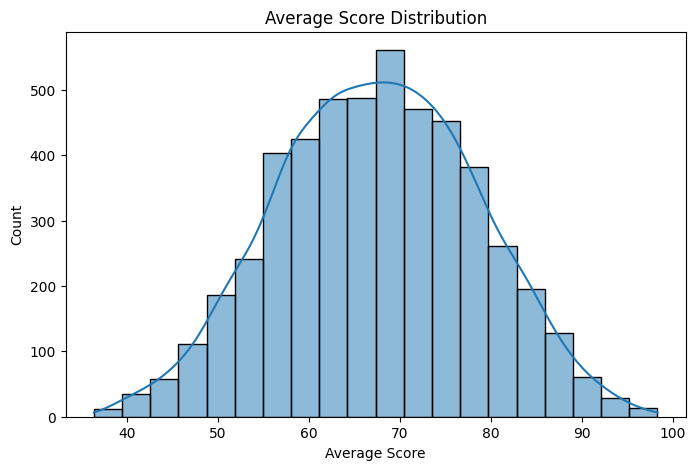

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["average_score"], bins=20, kde=True)

plt.title("Average Score Distribution")
plt.xlabel("Average Score")
plt.ylabel("Count")

plt.show()

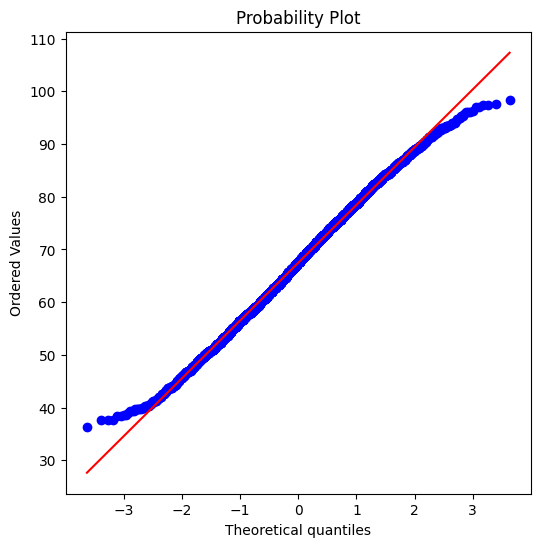

In [39]:
from scipy import stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

stats.probplot(df["average_score"], dist="norm", plot=plt)

plt.title("Probability Plot")

plt.show()

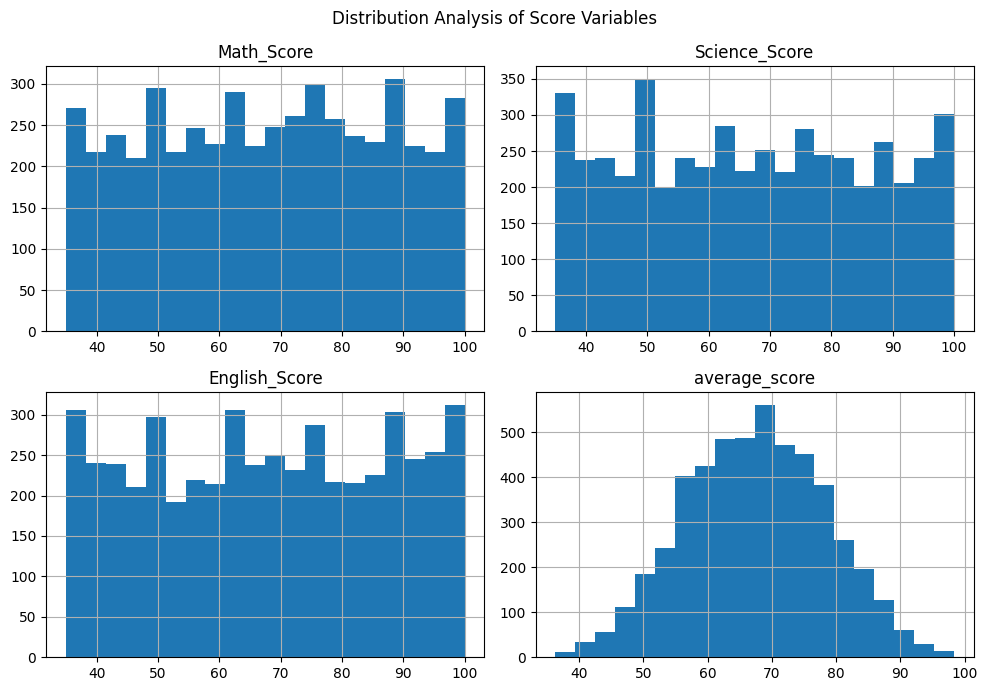

In [40]:
import matplotlib.pyplot as plt

score_columns = [
    "Math_Score",
    "Science_Score",
    "English_Score",
    "average_score"
]

df[score_columns].hist(
    figsize=(10, 7),
    bins=20
)

plt.suptitle("Distribution Analysis of Score Variables")
plt.tight_layout()
plt.show()

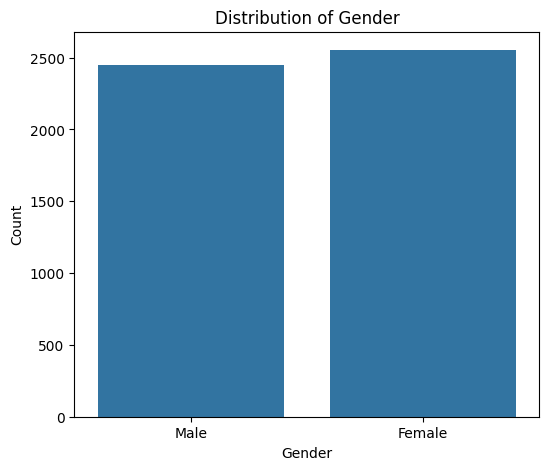

In [41]:
plt.figure(figsize=(6,5))

sns.countplot(x=df["Gender"])

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

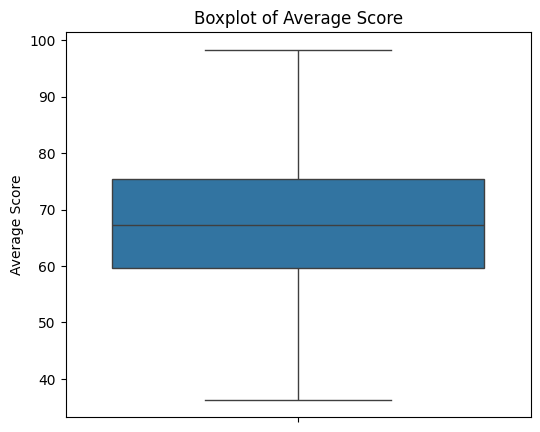

In [42]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["average_score"])

plt.title("Boxplot of Average Score")
plt.ylabel("Average Score")

plt.show()

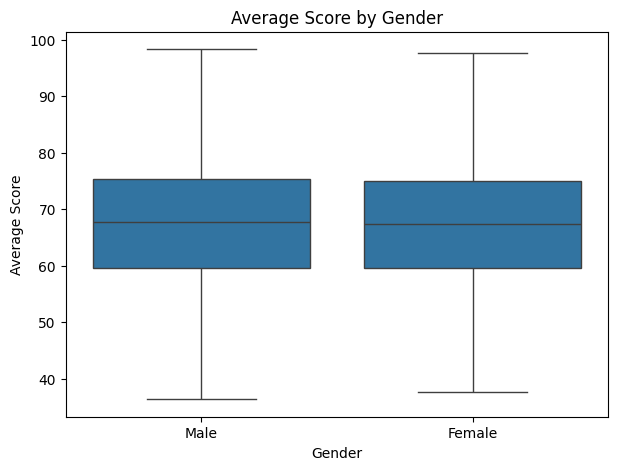

In [43]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["Gender"],
    y=df["average_score"]
)

plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.show()

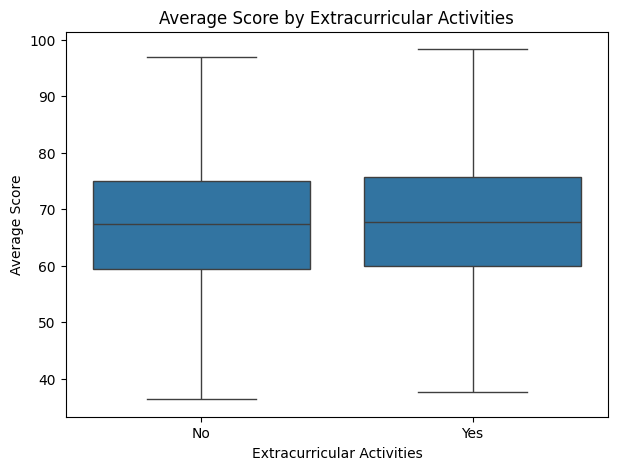

In [44]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["Extracurricular_Activities"],
    y=df["average_score"]
)

plt.title("Average Score by Extracurricular Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Average Score")

plt.show()

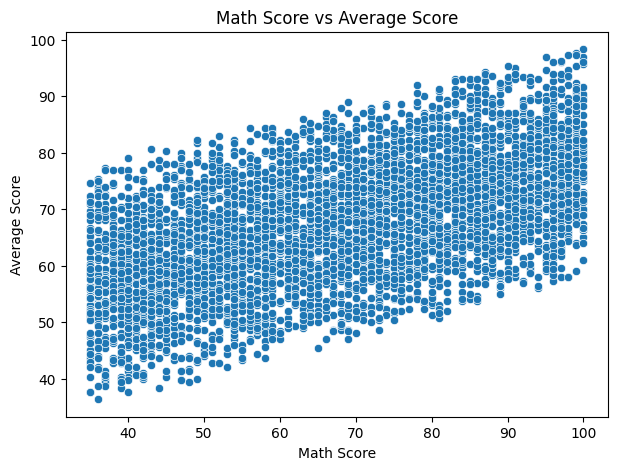

In [45]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Math_Score"],
    y=df["average_score"]
)

plt.title("Math Score vs Average Score")
plt.xlabel("Math Score")
plt.ylabel("Average Score")

plt.show()

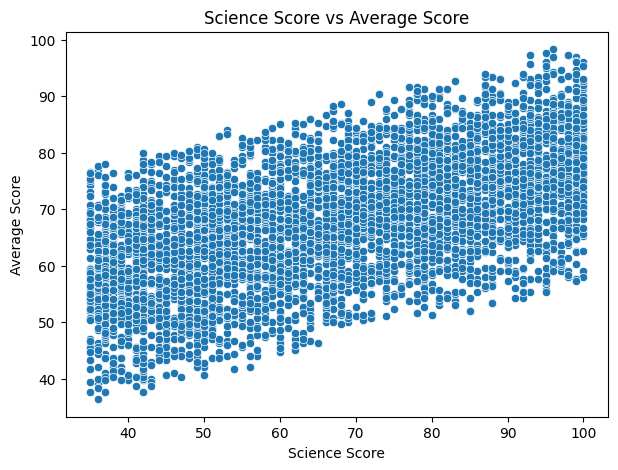

In [46]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Science_Score"],
    y=df["average_score"]
)

plt.title("Science Score vs Average Score")
plt.xlabel("Science Score")
plt.ylabel("Average Score")

plt.show()

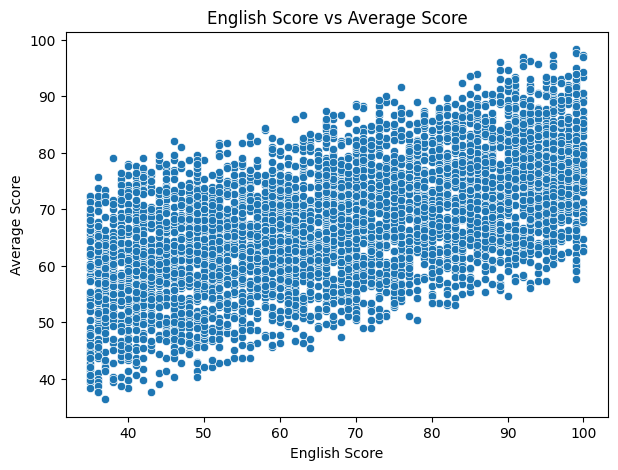

In [47]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["English_Score"],
    y=df["average_score"]
)

plt.title("English Score vs Average Score")
plt.xlabel("English Score")
plt.ylabel("Average Score")

plt.show()

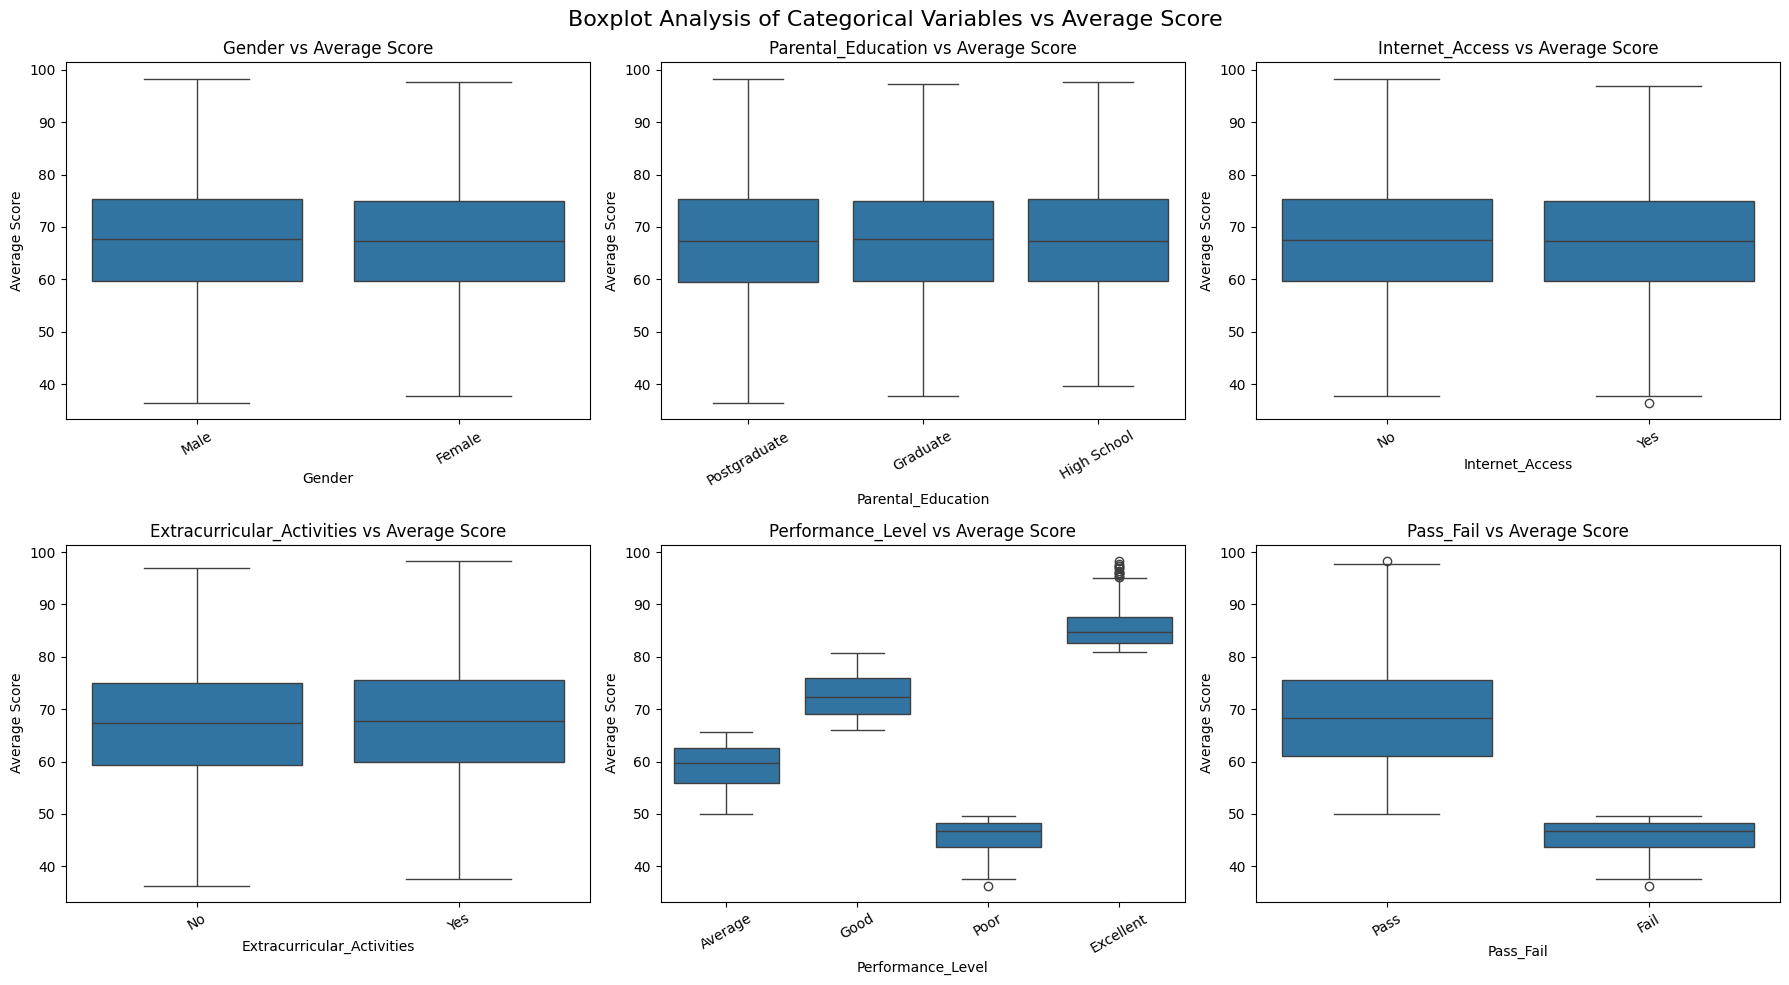

In [48]:
categorical_cols = [
    "Gender",
    "Parental_Education",
    "Internet_Access",
    "Extracurricular_Activities",
    "Performance_Level",
    "Pass_Fail"
]

plt.figure(figsize=(18, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], y=df["average_score"])
    plt.title(f"{col} vs Average Score")
    plt.xlabel(col)
    plt.ylabel("Average Score")
    plt.xticks(rotation=30)

plt.suptitle("Boxplot Analysis of Categorical Variables vs Average Score", fontsize=16)
plt.tight_layout()
plt.show()

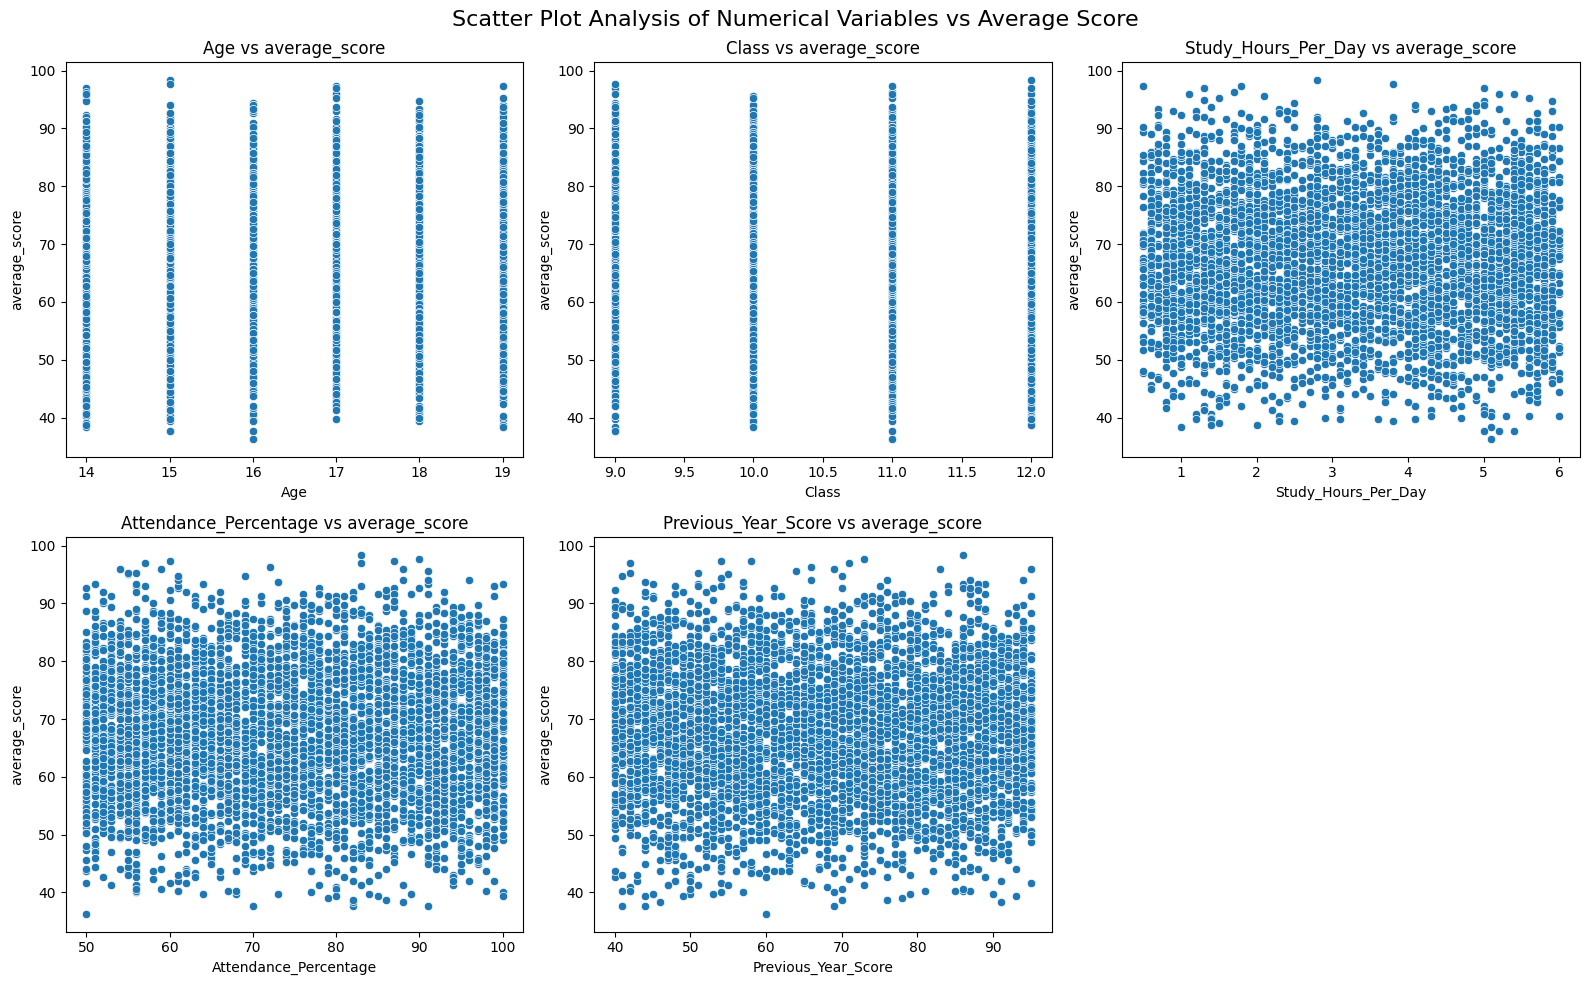

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    "Age",
    "Class",
    "Study_Hours_Per_Day",
    "Attendance_Percentage",
    "Previous_Year_Score"
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=col, y="average_score")
    plt.title(f"{col} vs average_score")
    plt.xlabel(col)
    plt.ylabel("average_score")

plt.suptitle("Scatter Plot Analysis of Numerical Variables vs Average Score", fontsize=16)
plt.tight_layout()
plt.show()

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df.drop(
    [
        "Student_ID",
        "average_score",
        "Final_Percentage",
        "Performance_Level",
        "Pass_Fail",
        "Math_Score",
        "Science_Score",
        "English_Score"
    ],
    axis=1
)

y = df["average_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 8.954701177358542
MSE: 119.58961971358475
RMSE: 10.935703896575873
R2 Score: -0.0064296824873482095


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 9.15178333333333
MSE: 125.87232145555554
RMSE: 11.2192834644444
R2 Score: -0.05930297980594568


In [52]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE: 12.873333333333331
MSE: 251.5768888888889
RMSE: 15.86117552039851
R2 Score: -1.1171941930411355


In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, None],
    "model__min_samples_split": [2, 5]
}

rf_tuned = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    rf_tuned,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Score: -120.66710447270722


In [54]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("MAE:", mae_tuned)
print("MSE:", mse_tuned)
print("RMSE:", rmse_tuned)
print("R2 Score:", r2_tuned)

Tuned Random Forest Results
MAE: 8.965958976631843
MSE: 119.72410200449725
RMSE: 10.941850940517206
R2 Score: -0.007561444338145984


In [55]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Decision Tree",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_dt,
        mae_tuned
    ],
    "MSE": [
        mse_lr,
        mse_rf,
        mse_dt,
        mse_tuned
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_dt,
        rmse_tuned
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_dt,
        r2_tuned
    ]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,8.954701,119.589620,10.935704,-0.006430
1,Random Forest,9.151783,125.872321,11.219283,-0.059303
2,Decision Tree,12.873333,251.576889,15.861176,-1.117194
3,Tuned Random Forest,8.965959,119.724102,10.941851,-0.007561


In [56]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Linear Regression": y_pred_lr[:10],
    "Random Forest": y_pred_rf[:10],
    "Decision Tree": y_pred_dt[:10],
    "Tuned Random Forest": y_pred_tuned[:10]
})

comparison_df

,Actual,Linear Regression,Random Forest,Decision Tree,Tuned Random Forest
0,59.333333,67.859322,66.083333,71.666667,67.901253
1,63.333333,67.506348,67.533333,72.333333,67.497348
2,61.000000,66.901446,63.076667,64.666667,67.416966
3,69.000000,67.023368,63.433333,64.000000,67.029611
4,72.666667,66.751366,68.290000,47.666667,67.368509
5,69.000000,67.018663,71.876667,73.333333,67.340710
6,59.000000,66.991085,68.393333,70.666667,67.436298
7,82.000000,67.549670,68.780000,59.333333,68.109005
8,63.333333,68.568263,66.630000,76.333333,68.191792
9,54.000000,68.760825,67.063333,43.000000,68.544346


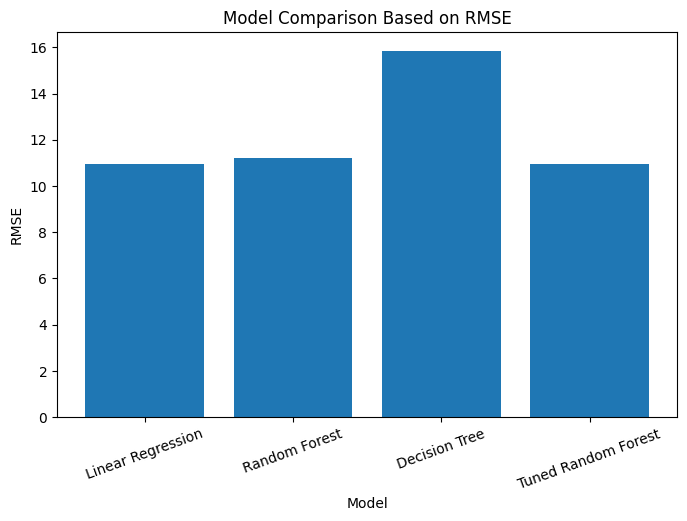

In [57]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.show()

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²:", ridge_r2)

Ridge Regression Results
MAE: 8.954687400546772
RMSE: 10.935687388919883
R²: -0.00642664403960036


In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression Results")
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)
print("R²:", lasso_r2)

Lasso Regression Results
MAE: 8.95164337953924
RMSE: 10.932455058048587
R²: -0.005831780081769544


In [62]:
!pip install xgboost

In [63]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Regression Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)


XGBoost Regression Results
MAE: 9.056774678548177
RMSE: 11.086808428806746
R²: -0.034434600431415996


In [64]:
print(y_train.describe())
print(y_test.describe())

count    4000.000000
mean       67.579500
std        10.977569
min        36.333333
25%        59.666667
50%        67.333333
75%        75.333333
max        98.333333
Name: average_score, dtype: float64
count    1000.000000
mean       67.070333
std        10.906170
min        38.666667
25%        59.000000
50%        67.500000
75%        75.000000
max        96.000000
Name: average_score, dtype: float64


In [65]:
xgb_model_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_model_2.fit(X_train, y_train)

xgb_pred_2 = xgb_model_2.predict(X_test)

xgb2_mae = mean_absolute_error(y_test, xgb_pred_2)
xgb2_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred_2))
xgb2_r2 = r2_score(y_test, xgb_pred_2)

print("Tuned XGBoost Regression Results")
print("MAE:", xgb2_mae)
print("RMSE:", xgb2_rmse)
print("R²:", xgb2_r2)

Tuned XGBoost Regression Results
MAE: 9.050201079050701
RMSE: 11.057314367568193
R²: -0.028938141203912693


In [66]:
new_results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        ridge_mae,
        lasso_mae,
        xgb_mae,
        xgb2_mae
    ],
    "RMSE": [
        ridge_rmse,
        lasso_rmse,
        xgb_rmse,
        xgb2_rmse
    ],
    "R²": [
        ridge_r2,
        lasso_r2,
        xgb_r2,
        xgb2_r2
    ]
})

new_results

,Model,MAE,RMSE,R²
0,Ridge Regression,8.954687,10.935687,-0.006427
1,Lasso Regression,8.951643,10.932455,-0.005832
2,XGBoost,9.056775,11.086808,-0.034435
3,Tuned XGBoost,9.050201,11.057314,-0.028938
